## Rainfields rainfall Product
1. prcp-crate
2. prcp-m15
3. lr-prcp-crate

### Individual radar domain

In [17]:
import os
import xarray as xr
import requests
import zipfile
import matplotlib.pyplot as plt

In [18]:
def download_file(url, local_filename):
    print(f"Downloading {url}...")
    response = requests.get(url, stream=True)
    response.raise_for_status()
    with open(local_filename, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f"Successfully downloaded {local_filename}")
    return local_filename

def extract_zip(zip_file, extract_dir):
    print(f"Extracting {zip_file} to {extract_dir}...")
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction completed")
    return extract_dir
    

In [19]:
zip_file_url = "https://thredds.nci.org.au/thredds/fileServer/rq0/rainfields3/2/2024/prcp-crate/2_20240101.prcp-crate.zip"
local_zip_filename = "2_20240101.prcp-crate.zip"
extracted_dir = "./extracted_data"

download_file(zip_file_url,local_zip_filename)
extract_zip(local_zip_filename,extracted_dir)


Successfully downloaded 2_20240101.prcp-crate.zip
Extracting 2_20240101.prcp-crate.zip to ./extracted_data...
Extraction completed


'./extracted_data'

In [20]:
! ls extracted_data

2_20240101_000000.prcp-crate.nc  2_20240101_120500.prcp-crate.nc
2_20240101_000500.prcp-crate.nc  2_20240101_121000.prcp-crate.nc
2_20240101_001000.prcp-crate.nc  2_20240101_121500.prcp-crate.nc
2_20240101_001500.prcp-crate.nc  2_20240101_122000.prcp-crate.nc
2_20240101_002000.prcp-crate.nc  2_20240101_122500.prcp-crate.nc
2_20240101_002500.prcp-crate.nc  2_20240101_123000.prcp-crate.nc
2_20240101_003000.prcp-crate.nc  2_20240101_123500.prcp-crate.nc
2_20240101_003500.prcp-crate.nc  2_20240101_124000.prcp-crate.nc
2_20240101_004000.prcp-crate.nc  2_20240101_124500.prcp-crate.nc
2_20240101_004500.prcp-crate.nc  2_20240101_125000.prcp-crate.nc
2_20240101_005000.prcp-crate.nc  2_20240101_125500.prcp-crate.nc
2_20240101_005500.prcp-crate.nc  2_20240101_130000.prcp-crate.nc
2_20240101_010000.prcp-crate.nc  2_20240101_130500.prcp-crate.nc
2_20240101_010500.prcp-crate.nc  2_20240101_131000.prcp-crate.nc
2_20240101_011000.prcp-crate.nc  2_20240101_131500.prcp-crate.nc
2_20240101_011500.prcp-cr

In [21]:
da = xr.open_dataset('./extracted_data/2_20240101_125000.prcp-crate.nc')
da

<xarray.Dataset>
Dimensions:     (y: 512, n2: 2, x: 512)
Coordinates:
  * y           (y) float64 127.8 127.2 126.8 126.2 ... -126.8 -127.2 -127.8
  * x           (x) float64 -127.8 -127.2 -126.8 -126.2 ... 126.8 127.2 127.8
Dimensions without coordinates: n2
Data variables:
    valid_time  datetime64[ns] ...
    proj        int8 ...
    y_bounds    (y, n2) float64 ...
    x_bounds    (x, n2) float64 ...
    rain_rate   (y, x) float32 ...
Attributes:
    Conventions:   CF-1.7
    title:         Radar derived rain rate
    institution:   Commonwealth of Australia, Bureau of Meteorology (ABN 92 6...
    licence:       http://www.bom.gov.au/other/copyright.shtml
    source:        rainfields 3.3.0 2023-11-21
    station_id:    2
    station_name:  Melb

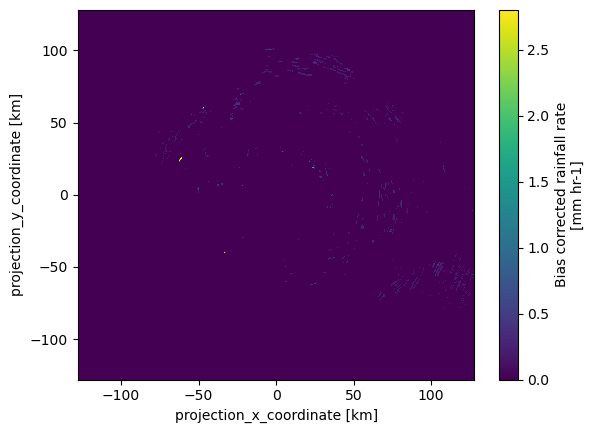

In [22]:
da.rain_rate.plot()

### Reading national moasic calibrated radar data

In [23]:
zip_file_url = "https://thredds.nci.org.au/thredds/fileServer/rq0/rainfields3/310/2024/prcp-crate/310_20240101.prcp-crate.zip"
local_zip_filename = "310_20240101.prcp-crate.zip"

download_file(zip_file_url,local_zip_filename)
extract_zip(local_zip_filename,extracted_dir)

Successfully downloaded 310_20240101.prcp-crate.zip
Extracting 310_20240101.prcp-crate.zip to ./extracted_data...
Extraction completed


'./extracted_data'

In [26]:
! ls ./extracted_data/310*.nc

./extracted_data/310_20240101_000000.prcp-crate.nc
./extracted_data/310_20240101_000500.prcp-crate.nc
./extracted_data/310_20240101_001000.prcp-crate.nc
./extracted_data/310_20240101_001500.prcp-crate.nc
./extracted_data/310_20240101_002000.prcp-crate.nc
./extracted_data/310_20240101_002500.prcp-crate.nc
./extracted_data/310_20240101_003000.prcp-crate.nc
./extracted_data/310_20240101_003500.prcp-crate.nc
./extracted_data/310_20240101_004000.prcp-crate.nc
./extracted_data/310_20240101_004500.prcp-crate.nc
./extracted_data/310_20240101_005000.prcp-crate.nc
./extracted_data/310_20240101_005500.prcp-crate.nc
./extracted_data/310_20240101_010000.prcp-crate.nc
./extracted_data/310_20240101_010500.prcp-crate.nc
./extracted_data/310_20240101_011000.prcp-crate.nc
./extracted_data/310_20240101_011500.prcp-crate.nc
./extracted_data/310_20240101_012000.prcp-crate.nc
./extracted_data/310_20240101_012500.prcp-crate.nc
./extracted_data/310_20240101_013000.prcp-crate.nc
./extracted_data/310_20240101_0

In [28]:
da_national = xr.open_dataset('./extracted_data/310_20240101_080500.prcp-crate.nc')
da_national

<xarray.Dataset>
Dimensions:     (y: 2050, n2: 2, x: 2450)
Coordinates:
  * y           (y) float64 -1.001e+03 -1.003e+03 ... -5.097e+03 -5.099e+03
  * x           (x) float64 -2.299e+03 -2.297e+03 ... 2.597e+03 2.599e+03
Dimensions without coordinates: n2
Data variables:
    valid_time  datetime64[ns] ...
    proj        int8 ...
    y_bounds    (y, n2) float64 ...
    x_bounds    (x, n2) float64 ...
    rain_rate   (y, x) float32 ...
Attributes:
    Conventions:         CF-1.7
    contributing_sites:  [  2   3   4   5   6   7   8  14  15  16  17  19  22...
    institution:         Commonwealth of Australia, Bureau of Meteorology (AB...
    licence:             http://www.bom.gov.au/other/copyright.shtml
    source:              rainfields 3.3.0 2023-11-21
    station_id:          310
    station_name:        Ausm310
    title:               Bias Corrected Rainfall Rate Mosaic

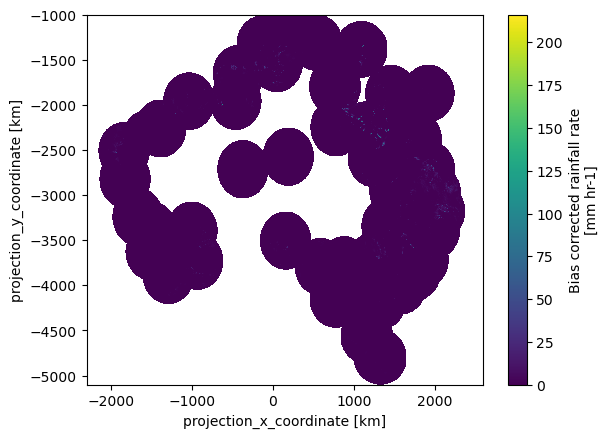

In [29]:
da_national.rain_rate.plot()

### prcp-m15 products

In [31]:
zip_file_url = "https://thredds.nci.org.au/thredds/fileServer/rq0/rainfields3/310/2025/prcp-m15/310_20251113.prcp-m15.zip"
local_zip_filename = "310_20251113.prcp-m15.zip"

download_file(zip_file_url,local_zip_filename)
extract_zip(local_zip_filename,extracted_dir)

Successfully downloaded 310_20251113.prcp-m15.zip
Extracting 310_20251113.prcp-m15.zip to ./extracted_data...
Extraction completed


'./extracted_data'

In [33]:
da_m15 = xr.open_dataset('./extracted_data/310_20251113_003000.prcp-m15.nc')
da_m15

<xarray.Dataset>
Dimensions:        (y: 2050, n2: 2, x: 2450)
Coordinates:
  * y              (y) float64 -1.001e+03 -1.003e+03 ... -5.097e+03 -5.099e+03
  * x              (x) float64 -2.299e+03 -2.297e+03 ... 2.597e+03 2.599e+03
Dimensions without coordinates: n2
Data variables:
    valid_time     datetime64[ns] ...
    start_time     datetime64[ns] ...
    proj           int8 ...
    y_bounds       (y, n2) float64 ...
    x_bounds       (x, n2) float64 ...
    precipitation  (y, x) float32 ...
Attributes:
    Conventions:         CF-1.7
    contributing_sites:  [  2   3   4   6   7   8  14  16  17  19  22  24  25...
    institution:         Commonwealth of Australia, Bureau of Meteorology (AB...
    licence:             http://www.bom.gov.au/other/copyright.shtml
    source:              rainfields 3.4.4
    station_id:          310
    station_name:        Ausm310
    title:               Merged Gauge/Radar Accumulation Mosaic (15 min)

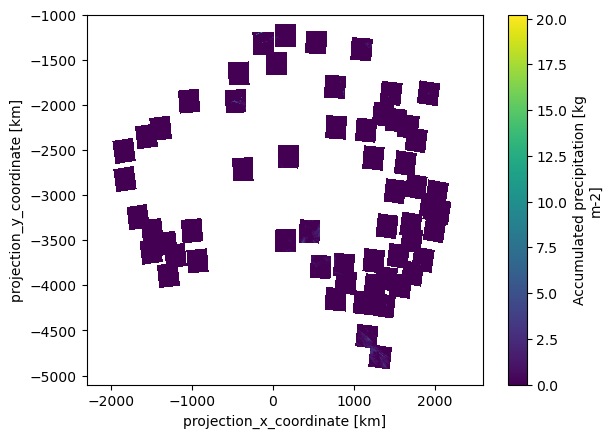

In [34]:
da_m15.precipitation.plot()